# Project:  Circuit Breaker Vibration Signal - Kurtogram- Image Identification using CNN

## Introdcution:
   
Circuit breakers are critical components in power systems, functioning as mechanical switching devices that protect electrical circuits from damage caused by overloads or short circuits.

Vibration-based condition monitoring is a non-invasive technique that allows us to detect the degradation process and assess the mechanical health of the equipment over time.

But, unlike other rotating machinery, the circuit breaker has a unique operational mechanism. Their vibration signals raise from dynamic switching actions (opening/closing):  These actions generate **transient, non-stationary, and non-linear** vibration signals. These characteristics make difficult for us to deal with the vibration data, for example,  **simple time-domain features (e.g., mean, RMS, kurtosis) are often insufficient or misleading due to the non-stationary nature of the data.**

**The goal of this project** is to demonstrate the effectiveness of transforming circuit breaker vibration signals into frequency-based kurtogram images, and using Convolutional Neural Networks (CNNs) to classify them into healthy and defective categories.

In [ ]:
from PIL import Image
from tqdm import tqdm
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import Keras (now part of TensorFlow)
from tensorflow.keras import datasets, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, ReLU, LeakyReLU, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

## 1. Load Images and Split them into Train, Validation, Test folder

In [ ]:
# first convert all images into RGB format

base_dir = "kurtogram_images"
converted_dir = "kurtogram_images_rgb"
os.makedirs(converted_dir, exist_ok=True)

for file in tqdm(os.listdir(base_dir), desc="Converting Images"):
    if file.endswith(".png"):
        img_path = os.path.join(base_dir, file)
        img = Image.open(img_path).convert("RGB") 
        img.save(os.path.join(converted_dir, file))

In [ ]:
base_dir = "kurtogram_images_rgb"
dataset_dir = "kurtogram_dataset"
os.makedirs(dataset_dir, exist_ok=True)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(dataset_dir, split, "0"), exist_ok=True)  # Functional CB (Healthy)
    os.makedirs(os.path.join(dataset_dir, split, "1"), exist_ok=True)  # Defective CB (Faulty)

image_files = sorted([f for f in os.listdir(base_dir) if f.endswith(".png")], key=lambda x: int(x.split("_")[-1].split(".")[0]))


In [ ]:
# Separate healthy and faulty images
healthy_images = image_files[:1000]  # First 1000 are Healthy (Label 0)
faulty_images = image_files[1000:]   # Last 1000 are Faulty (Label 1)

# 80% train, 20% test
train_healthy = healthy_images[:800] 
test_healthy = healthy_images[800:]  

train_faulty = faulty_images[:800]  
test_faulty = faulty_images[800:]  

# 20% of train - validation data
val_healthy = train_healthy[-160:] 
train_healthy = train_healthy[:-160] 
val_faulty = train_faulty[-160:]    
train_faulty = train_faulty[:-160] 

train_files = [(f, "0") for f in train_healthy] + [(f, "1") for f in train_faulty]
val_files = [(f, "0") for f in val_healthy] + [(f, "1") for f in val_faulty]
test_files = [(f, "0") for f in test_healthy] + [(f, "1") for f in test_faulty]

In [ ]:
for image_name, label in tqdm(train_files, desc="Organizing Train Set"):
    shutil.copy(os.path.join(base_dir, image_name), os.path.join(dataset_dir, "train", label, image_name))

for image_name, label in tqdm(val_files, desc="Organizing Validation Set"):
    shutil.copy(os.path.join(base_dir, image_name), os.path.join(dataset_dir, "val", label, image_name))

for image_name, label in tqdm(test_files, desc="Organizing Test Set"):
    shutil.copy(os.path.join(base_dir, image_name), os.path.join(dataset_dir, "test", label, image_name))


In [ ]:
print("Train Class 0:", len(os.listdir("kurtogram_dataset/train/0")))
print("Train Class 1:", len(os.listdir("kurtogram_dataset/train/1")))
print("Val Class 0:", len(os.listdir("kurtogram_dataset/val/0")))
print("Val Class 1:", len(os.listdir("kurtogram_dataset/val/1")))
print("Test Class 0:", len(os.listdir("kurtogram_dataset/test/0")))
print("Test Class 1:", len(os.listdir("kurtogram_dataset/test/1")))

Train Class 0: 640
Train Class 1: 640
Val Class 0: 160
Val Class 1: 160
Test Class 0: 200
Test Class 1: 200


## 2. Prepare Images for CNN

In [ ]:
# choose image size 
## 128 * 128 is often used for CNN
## 224 * 224 for ResNet or VGG16 models

# Rescaling images
## pixel values in [0, 255]
## 1/255  --[0,1]

IMG_SIZE = (128, 128) 
BATCH_SIZE = 32

# Image Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# No need for validation & test, only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb"  
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb"
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

Found 1280 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


## 3. Build a CNN Model

In [8]:
IMG_SIZE

(128, 128)

In [ ]:
model = Sequential()

# First Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(128, 128, 3), padding='same', activation='relu', name='Conv2D_1' ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, name ='Maxpool_1'))

# Second Convolutional Layer
model.add(Conv2D(filters=48, kernel_size=(3,3), padding='same', activation='relu', name='Conv2D_2' ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, name ='Maxpool_2'))

# Third Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', name='Conv2D_3' ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, name ='Maxpool_3'))

# flatten
model.add(Flatten(name='Flatten'))

# fully connected layers
model.add(Dense(128, activation='relu',name = 'Dense_1'))
model.add(Dropout(0.5, name='Dropout_1'))  

model.add(Dense(1, activation='sigmoid'))

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv2D_1 (Conv2D)           (None, 128, 128, 64)      1792      
                                                                 
 Maxpool_1 (MaxPooling2D)    (None, 64, 64, 64)        0         
                                                                 
 Conv2D_2 (Conv2D)           (None, 64, 64, 48)        27696     
                                                                 
 Maxpool_2 (MaxPooling2D)    (None, 32, 32, 48)        0         
                                                                 
 Conv2D_3 (Conv2D)           (None, 32, 32, 32)        13856     
                                                                 
 Maxpool_3 (MaxPooling2D)    (None, 16, 16, 32)        0         
                                                                 
 Flatten (Flatten)           (None, 8192)              0

In [ ]:
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])


In [41]:
history = model.fit(train_generator, 
                    validation_data=val_generator,
                    epochs=50, 
                    batch_size=32)

Epoch 1/50
40/40 [==============================] - 19s 469ms/step - loss: 0.7044 - accuracy: 0.5063 - val_loss: 0.6889 - val_accuracy: 0.5719
Epoch 2/50
40/40 [==============================] - 18s 462ms/step - loss: 0.6881 - accuracy: 0.5469 - val_loss: 0.6725 - val_accuracy: 0.5813
Epoch 3/50
40/40 [==============================] - 18s 458ms/step - loss: 0.6801 - accuracy: 0.5938 - val_loss: 0.6763 - val_accuracy: 0.5969
Epoch 4/50
40/40 [==============================] - 18s 453ms/step - loss: 0.6785 - accuracy: 0.5789 - val_loss: 0.6572 - val_accuracy: 0.6156
Epoch 5/50
40/40 [==============================] - 18s 460ms/step - loss: 0.6598 - accuracy: 0.6305 - val_loss: 0.6536 - val_accuracy: 0.5875
Epoch 6/50
40/40 [==============================] - 18s 460ms/step - loss: 0.6554 - accuracy: 0.6125 - val_loss: 0.6257 - val_accuracy: 0.6156
Epoch 7/50
40/40 [==============================] - 18s 455ms/step - loss: 0.6532 - accuracy: 0.6273 - val_loss: 0.6177 - val_accuracy: 0.6375

In [45]:

model.save("CNN_model.h5")


In [42]:
# Evaluate model on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f" Test Accuracy: {test_acc:.2%}")

13/13 [==============================] - 6s 428ms/step - loss: 0.5009 - accuracy: 0.8700
 Test Accuracy: 87.00%


13/13 [==============================] - 4s 312ms/step


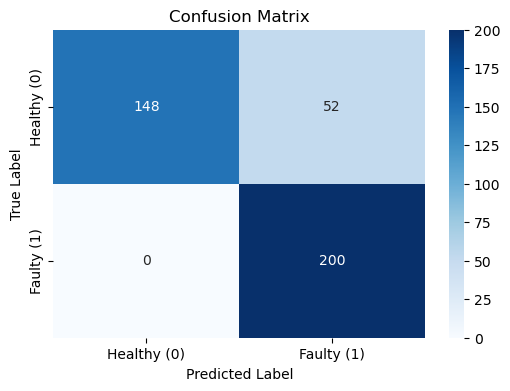

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.74      0.85       200
           1       0.79      1.00      0.88       200

    accuracy                           0.87       400
   macro avg       0.90      0.87      0.87       400
weighted avg       0.90      0.87      0.87       400



In [ ]:

y_true = test_generator.classes 
y_pred_prob = model.predict(test_generator) 
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary labels (0 or 1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy (0)", "Faulty (1)"], yticklabels=["Healthy (0)", "Faulty (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n", classification_report(y_true, y_pred))